aim to built a loan default prediction model using a datasets. 

In [146]:
import pandas as pd
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
import numpy as np
import scipy 

In [114]:
# Load German Credit dataset
ds = fetch_ucirepo(id=144)
X, y = ds.data.features, ds.data.targets

In [115]:
#print the first five record of data
X.head()

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,Attribute11,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201


In [116]:
#shape of the data 
print(f"shape of the datasets features {X.shape} and label {y.shape}")
# distribution of the dataset
print(f"Distribution of X {X.describe()} and distribution of y {y.describe()}")

shape of the datasets features (1000, 20) and label (1000, 1)
Distribution of X         Attribute2    Attribute5   Attribute8  Attribute11  Attribute13  \
count  1000.000000   1000.000000  1000.000000  1000.000000  1000.000000   
mean     20.903000   3271.258000     2.973000     2.845000    35.546000   
std      12.058814   2822.736876     1.118715     1.103718    11.375469   
min       4.000000    250.000000     1.000000     1.000000    19.000000   
25%      12.000000   1365.500000     2.000000     2.000000    27.000000   
50%      18.000000   2319.500000     3.000000     3.000000    33.000000   
75%      24.000000   3972.250000     4.000000     4.000000    42.000000   
max      72.000000  18424.000000     4.000000     4.000000    75.000000   

       Attribute16  Attribute18  
count  1000.000000  1000.000000  
mean      1.407000     1.155000  
std       0.577654     0.362086  
min       1.000000     1.000000  
25%       1.000000     1.000000  
50%       1.000000     1.000000  
75%   

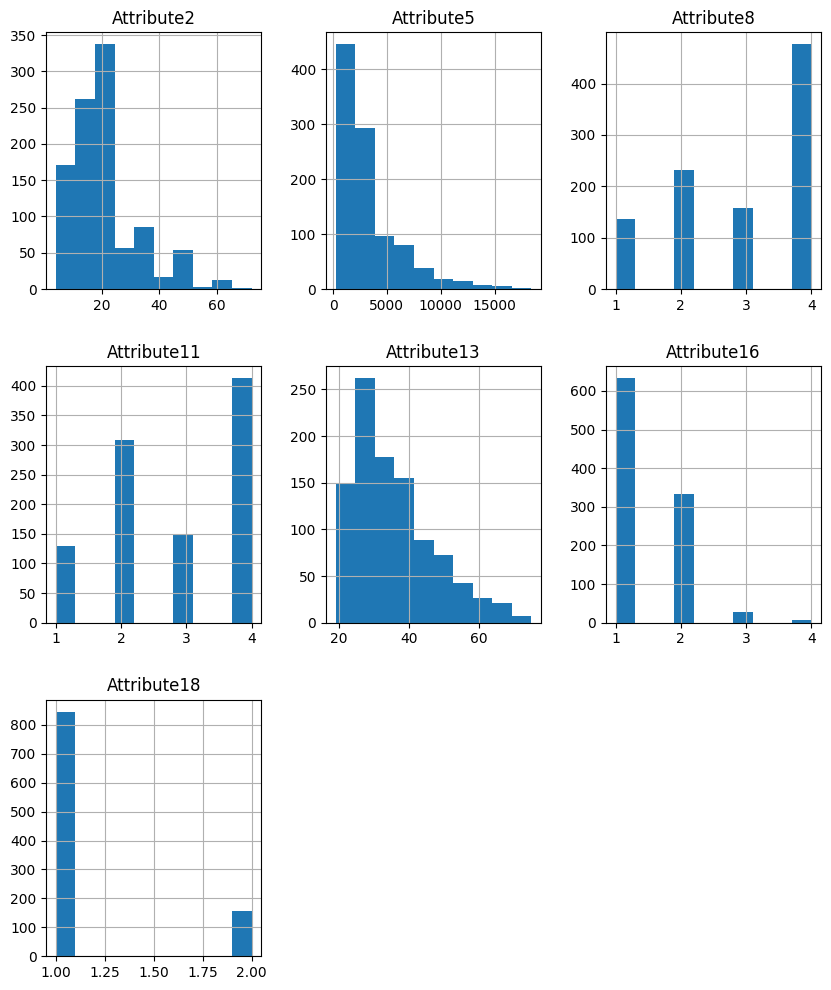

In [117]:
axes = X.hist(figsize=(10,12)) #  shows the histogram for the numerical attrributes 

Several attributes (8, 11, 16, 18) are categorical, not continuous. There are imbalanced distributions in multiple variables, which could matter for modeling. attribute 5 (credit_amount), the distribution is right skewed. Most values are very low(zero to approximately 3000) but there is a long tail reaching approximately 18000. 

As this datasets classifies people describe by a set of attributes as good or bad credit risks. The datasets contains 100 columns and 20 features. this datasets has a target attribute, it is supervised learning and After looking at the datasets, all column names are encoded. 

In [118]:
y.value_counts()

class
1        700
2        300
Name: count, dtype: int64

target variable indicate class imbalance

### Datacleaning

In [119]:
X = X.rename(columns={
    'Attribute1':  'checking_account_status',
    'Attribute2':  'duration_months',
    'Attribute3':  'credit_history',
    'Attribute4':  'purpose',
    'Attribute5':  'credit_amount',
    'Attribute6':  'savings_account',
    'Attribute7':  'employment_since',
    'Attribute8':  'installment_rate_pct',
    'Attribute9':  'personal_status_sex',
    'Attribute10': 'other_debtors_guarantors',
    'Attribute11': 'residence_since',
    'Attribute12': 'property',
    'Attribute13': 'age',
    'Attribute14': 'other_installment_plans',
    'Attribute15': 'housing',
    'Attribute16': 'existing_credits_count',
    'Attribute17': 'job',
    'Attribute18': 'dependants_count',
    'Attribute19': 'telephone',
    'Attribute20': 'foreign_worker'
})

In [120]:
y = y.rename(columns={'class': 'credit_risks'})


In [121]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   checking_account_status   1000 non-null   str  
 1   duration_months           1000 non-null   int64
 2   credit_history            1000 non-null   str  
 3   purpose                   1000 non-null   str  
 4   credit_amount             1000 non-null   int64
 5   savings_account           1000 non-null   str  
 6   employment_since          1000 non-null   str  
 7   installment_rate_pct      1000 non-null   int64
 8   personal_status_sex       1000 non-null   str  
 9   other_debtors_guarantors  1000 non-null   str  
 10  residence_since           1000 non-null   int64
 11  property                  1000 non-null   str  
 12  age                       1000 non-null   int64
 13  other_installment_plans   1000 non-null   str  
 14  housing                   1000 non-null   str  
 15 

### column types 
#### split the columns in category and numerical and change its type

In [125]:
#to select categorical column
cat_col = X.select_dtypes(include = ['str','category']).columns.tolist()
print(f"categorical columns: {cat_col}")

categorical columns: ['checking_account_status', 'credit_history', 'purpose', 'savings_account', 'employment_since', 'personal_status_sex', 'other_debtors_guarantors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']


In [123]:
num_col = X.select_dtypes(include = ["number"]).columns.tolist()
print(f"numerical columns: {num_col}")

numerical columns: ['duration_months', 'credit_amount', 'installment_rate_pct', 'residence_since', 'age', 'existing_credits_count', 'dependants_count']


In [124]:
y['credit_risks'] = y['credit_risks'].astype('int64')

### check nullvalues 

In [126]:
print(f"null values {X.isna().sum()}")
print(f"null values in y column {y.isna().sum()}")

null values checking_account_status     0
duration_months             0
credit_history              0
purpose                     0
credit_amount               0
savings_account             0
employment_since            0
installment_rate_pct        0
personal_status_sex         0
other_debtors_guarantors    0
residence_since             0
property                    0
age                         0
other_installment_plans     0
housing                     0
existing_credits_count      0
job                         0
dependants_count            0
telephone                   0
foreign_worker              0
dtype: int64
null values in y column credit_risks    0
dtype: int64


In [127]:
#check class imbalance in the target column
y.value_counts()

credit_risks
1               700
2               300
Name: count, dtype: int64

In [131]:
y.isna().sum()


credit_risks    0
dtype: int64

In [132]:
y = y.squeeze()

In [130]:
for col in num_col:
    print(col, X[col].isna().sum())

duration_months 0
credit_amount 0
installment_rate_pct 0
residence_since 0
age 0
existing_credits_count 0
dependants_count 0


The next  step is to check the distribution per class 

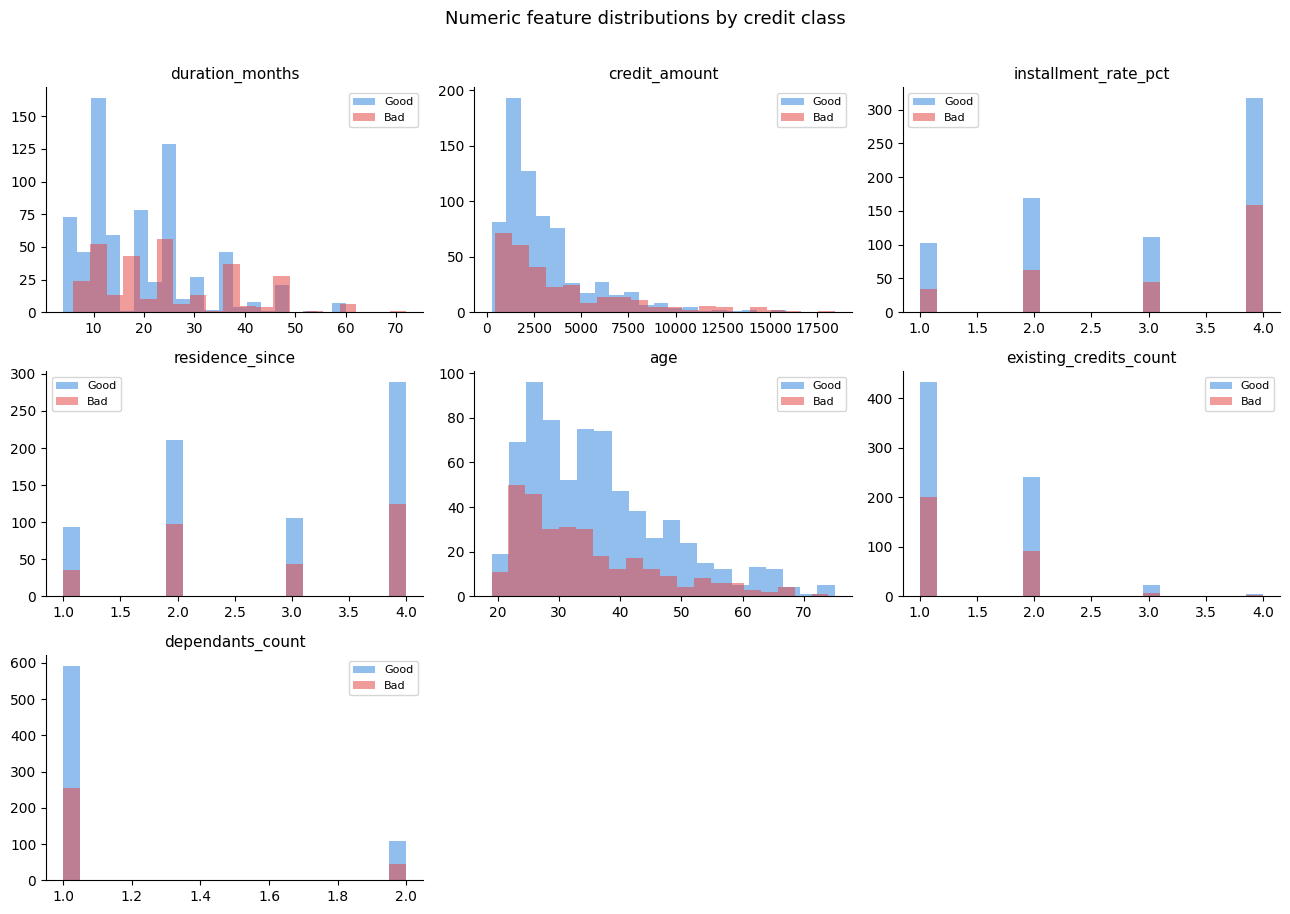

In [ ]:

fig, axes = plt.subplots(3, 3, figsize=(13, 9))
axes = axes.flatten()

for i, col in enumerate(num_col):
    ax = axes[i]
    for label, color, name in [(1, '#378ADD', 'Good'), (2, '#E24B4A', 'Bad')]:
        ax.hist(X[y == label][col], bins=20, alpha=0.55,
                color=color, label=name, edgecolor='none')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)

# Hide unused subplots
for j in range(len(num_col), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric feature distributions by credit class', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

C:\Users\IqraRafiq\AppData\Local\Temp\ipykernel_30760\4238930329.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_good, data_bad],
C:\Users\IqraRafiq\AppData\Local\Temp\ipykernel_30760\4238930329.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_good, data_bad],
C:\Users\IqraRafiq\AppData\Local\Temp\ipykernel_30760\4238930329.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_good, data_bad],
C:\Users\IqraRafiq\AppData\Local\Temp\ipykernel_30760\4238930329.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'ti

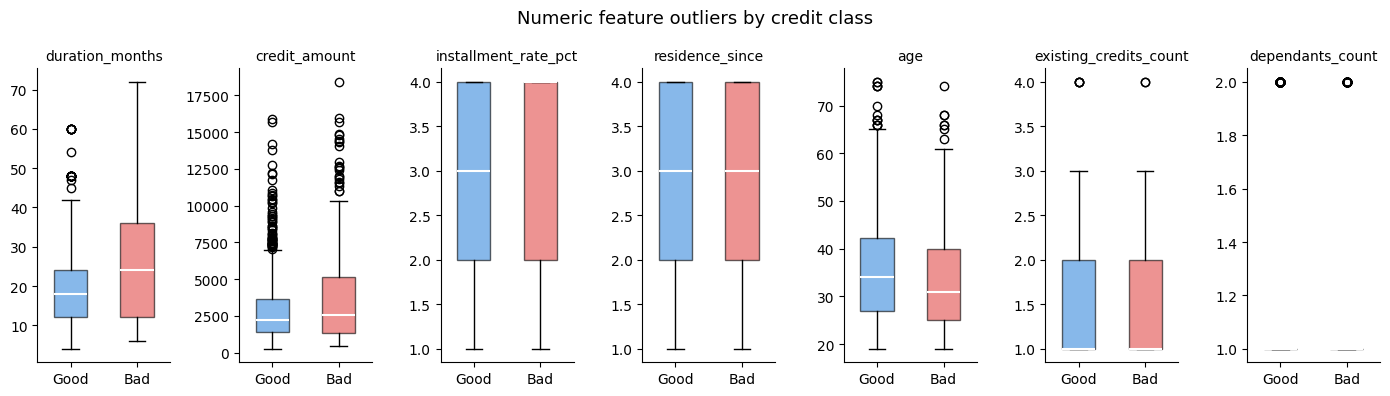

In [137]:
# --- 3b. Boxplots to spot outliers ---
fig, axes = plt.subplots(1, len(num_col), figsize=(14, 4))

for ax, col in zip(axes, num_col):
    data_good = X[y == 1][col]
    data_bad  = X[y == 2][col]
    bp = ax.boxplot([data_good, data_bad],
                    patch_artist=True,
                    labels=['Good', 'Bad'],
                    widths=0.5)
    bp['boxes'][0].set_facecolor('#378ADD')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('#E24B4A')
    bp['boxes'][1].set_alpha(0.6)
    for median in bp['medians']:
        median.set_color('white')
        median.set_linewidth(1.5)
    ax.set_title(col, fontsize=10)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Numeric feature outliers by credit class', fontsize=13)
plt.tight_layout()
plt.show()

In [145]:
#summary statistics

summary = pd.DataFrame()
for col in num_col:
    good = X[y == 1][col]
    bad  = X[y == 2][col]
    summary[col] = {
        'mean (good)':   round(good.mean(), 1),
        'mean (bad)':    round(bad.mean(), 1),
        'median (good)': round(good.median(), 1),
        'median (bad)':  round(bad.median(), 1),
        'outliers (>3 deviation)': int((np.abs((X[col] - X[col].mean()) / X[col].std()) > 3).sum())
    }
print(summary.T)
    

                        mean (good)  mean (bad)  median (good)  median (bad)  \
duration_months                19.2        24.9           18.0          24.0   
credit_amount                2985.5      3938.1         2244.0        2574.5   
installment_rate_pct            2.9         3.1            3.0           4.0   
residence_since                 2.8         2.8            3.0           3.0   
age                            36.2        34.0           34.0          31.0   
existing_credits_count          1.4         1.4            1.0           1.0   
dependants_count                1.2         1.2            1.0           1.0   

                        outliers (>3 deviation)  
duration_months                            14.0  
credit_amount                              25.0  
installment_rate_pct                        0.0  
residence_since                             0.0  
age                                         7.0  
existing_credits_count                      6.0  
dependant

### this statistical difference will tell which numeric feature differes between the two classes 


Mann-Whitney U is used instead of t test becasue it makes no assumptions about normal distribution as seen by the histogram above 

In [147]:
from scipy.stats import mannwhitneyu
print("Mann-Whitney U test — numeric features vs default label\n")
for col in num_col:
    good = X[y == 1][col]
    bad  = X[y == 2][col]
    stat, p = mannwhitneyu(good, bad, alternative='two-sided')
    sig = "SIGNIFICANT" if p < 0.05 else "not significant"
    print(f"{col:<30} p={p:.4f}  {sig}")

Mann-Whitney U test — numeric features vs default label

duration_months                p=0.0000  SIGNIFICANT
credit_amount                  p=0.0059  SIGNIFICANT
installment_rate_pct           p=0.0199  SIGNIFICANT
residence_since                p=0.9358  not significant
age                            p=0.0004  SIGNIFICANT
existing_credits_count         p=0.1348  not significant
dependants_count               p=0.9242  not significant


4 of 7 numeric features show statistically significant differences between good and bad credit classes (p < 0.05). `duration_months` is the clearest separator — its p-value of 0.0000 means the difference in loan duration between classes is extremely unlikely to be random. 
`age` is statistically significant despite the small mean gap which means distribution shape differs between the classes even the average look similar. Histogram (attribute 13)  `age` shows that it is dominated by the younger applicants are over represented in bad credit class. 
`residence_since` and `dependants_count` (p > 0.9) carry virtually no signal. Will confirm with SHAP after modelling — if importance is near zero, these will be dropped in a feature selection pass.

### Categorical features

Moving forward to the categorical features, first to identify the value count for each categorical feature. there plotting abr chart here to represent categorical values. 

IndexError: index 12 is out of bounds for axis 0 with size 12

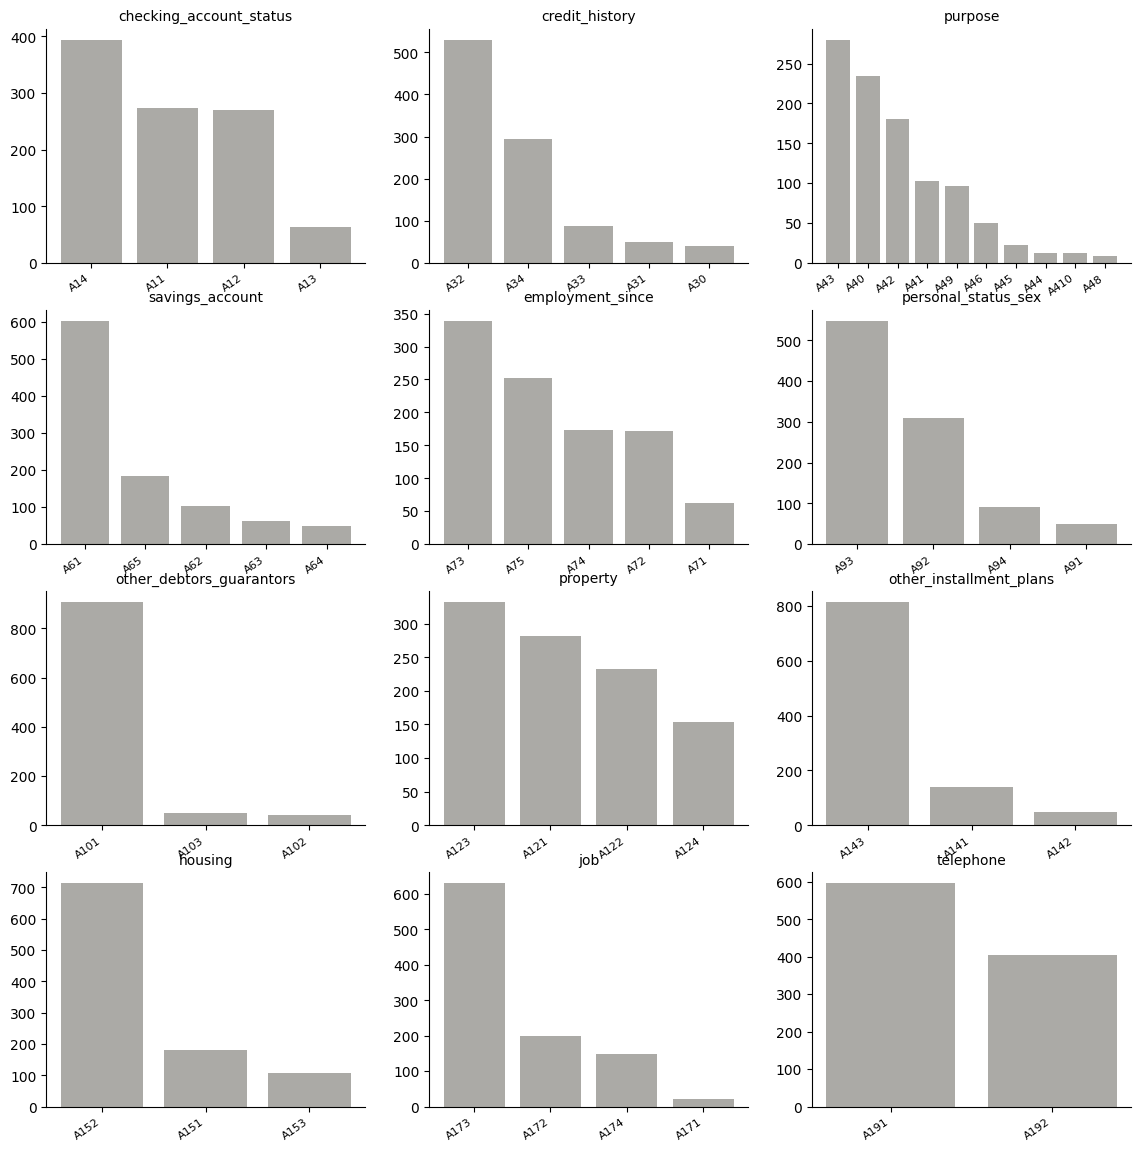

In [ ]:
# Value counts for each categorical feature
fig, axes = plt.subplots(4, 3, figsize=(14, 14))
axes = axes.flatten()
binary_target = (y == 2).astype(int)

for i, col in enumerate(cat_col):
    ax = axes[i]
    counts = df[col].value_counts()
    ax.bar(range(len(counts)), counts.values,
           color='#888780', alpha=0.7, edgecolor='none')
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=35, ha='right', fontsize=8)
    ax.set_title(col, fontsize=10)
    ax.spines[['top','right']].set_visible(False)

for j in range(len(cat_col), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Value counts — categorical features', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [160]:
import math
n = len(cat_col)

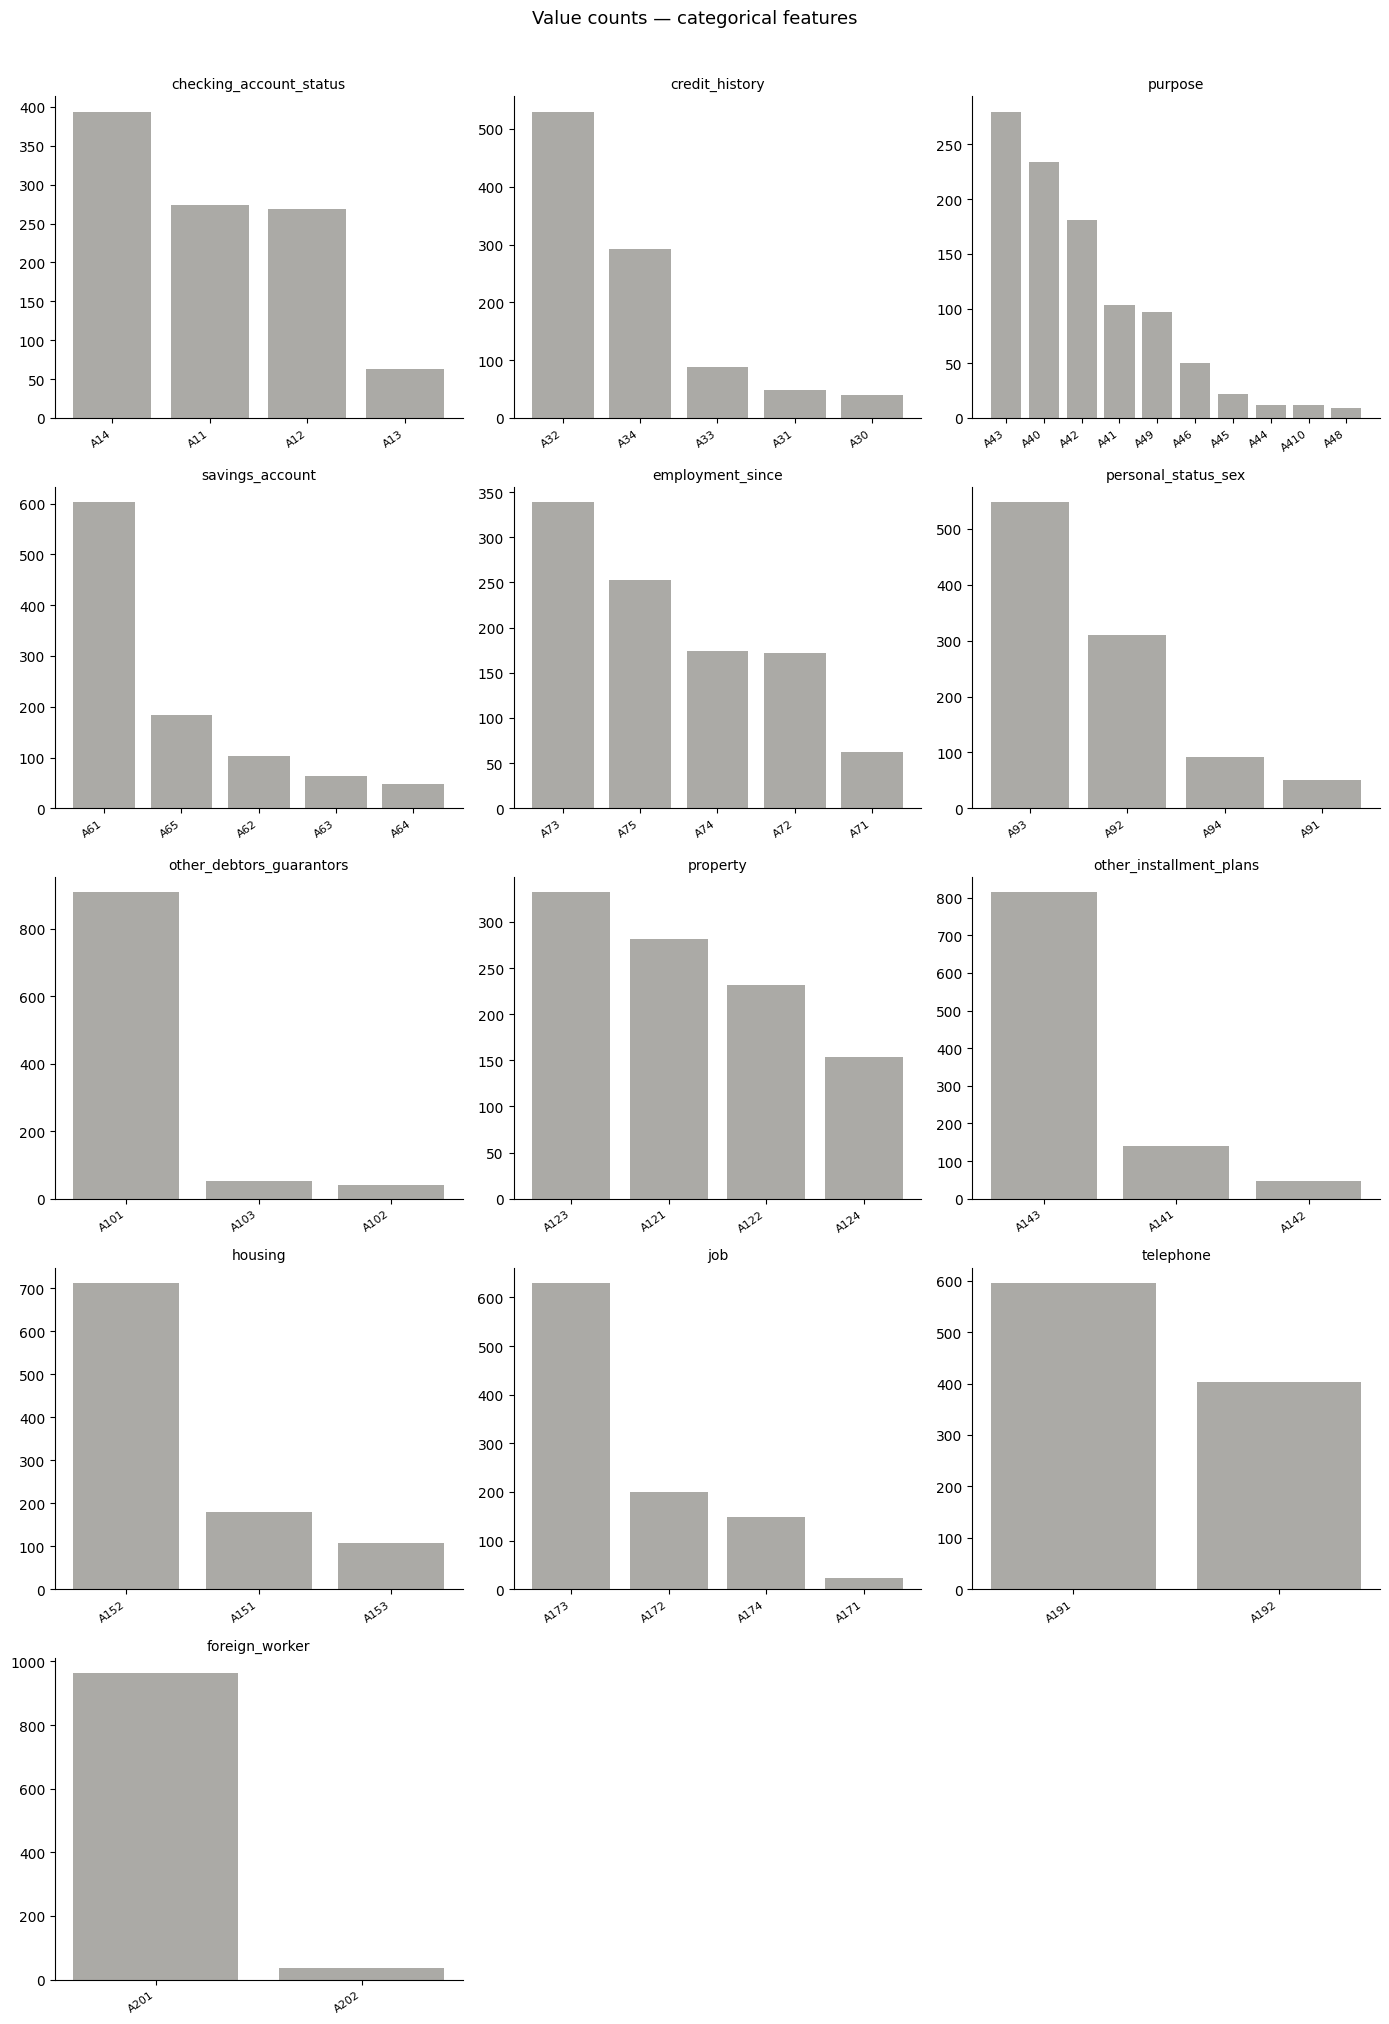

In [167]:
# Value counts for each categorical feature ---
import math
#since I got error that index 12 out of bound because the axes was flattened (length was fixed)
n = len(cat_col)
# i want 3 plots per row, then computed number of rows i needed
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows*4))
axes = axes.flatten()

for i, col in enumerate(cat_col):
    ax = axes[i]
    counts = X[col].value_counts()
    ax.bar(range(len(counts)), counts.values,
           color='#888780', alpha=0.7, edgecolor='none')
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=35, ha='right', fontsize=8)
    ax.set_title(col, fontsize=10)
    ax.spines[['top','right']].set_visible(False)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Value counts — categorical features', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

This step include the default rate per category. 

In [ ]:
y = bin

credit_risks
1    700
2    300
Name: count, dtype: int64

In [179]:
# --- 4b. Default rate per category (the most useful plot) ---
df = X.copy()
df['target'] = binary_target  # 1 = bad credit, 0 = good


In [ ]:

n = len(cat_col)
# i want 3 plots per row, then computed number of rows i needed
ncols = 3
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows*4))
axes = axes.flatten()

for i, col in enumerate(cat_col):
    ax = axes[i]
    rate = (X.groupby(col)['credit_risk']
              .mean()
              .sort_values(ascending=True))
    colors = ['#E24B4A' if v > 0.35 else
              '#BA7517' if v > 0.25 else
              '#378ADD' for v in rate.values]
    ax.barh(range(len(rate)), rate.values,
            color=colors, edgecolor='none', height=0.6)
    ax.set_yticks(range(len(rate)))
    ax.set_yticklabels(rate.index, fontsize=8)
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.set_title(col, fontsize=10)
    ax.spines[['top','right']].set_visible(False)

for j in range(len(cat_col), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Default rate by category value', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [170]:
# --- 4c. Print a ranked summary table ---
print("Default rate by category — top 5 riskiest values per feature\n")
for col in cat_col:
    rate = df.groupby(col)['target'].mean().sort_values(ascending=False)
    print(f"\n{col}:")
    print(rate.head(5).apply(lambda x: f"{x:.1%}").to_string())

Default rate by category — top 5 riskiest values per feature


checking_account_status:
checking_account_status
A11    49.3%
A12    39.0%
A13    22.2%
A14    11.7%

credit_history:
credit_history
A30    62.5%
A31    57.1%
A32    31.9%
A33    31.8%
A34    17.1%

purpose:
purpose
A46     44.0%
A410    41.7%
A40     38.0%
A45     36.4%
A49     35.1%

savings_account:
savings_account
A61    36.0%
A62    33.0%
A65    17.5%
A63    17.5%
A64    12.5%

employment_since:
employment_since
A72    40.7%
A71    37.1%
A73    30.7%
A75    25.3%
A74    22.4%

personal_status_sex:
personal_status_sex
A91    40.0%
A92    35.2%
A94    27.2%
A93    26.6%

other_debtors_guarantors:
other_debtors_guarantors
A102    43.9%
A101    30.0%
A103    19.2%

property:
property
A124    43.5%
A123    30.7%
A122    30.6%
A121    21.3%

other_installment_plans:
other_installment_plans
A141    41.0%
A142    40.4%
A143    27.5%

housing:
housing
A153    40.7%
A151    39.1%
A152    26.1%

job:
job
A174    34.5%
A171    31.

In [172]:
# Decode all categorical columns with human-readable labels
label_maps = {
    'checking_account_status': {
        'A11': '< 0 DM', 'A12': '0–200 DM',
        'A13': '> 200 DM', 'A14': 'no account'
    },
    'credit_history': {
        'A30': 'no credits taken', 'A31': 'all paid at bank',
        'A32': 'existing paid', 'A33': 'delay in past',
        'A34': 'critical account'
    },
    'purpose': {
        'A40': 'car (new)', 'A41': 'car (used)', 'A42': 'furniture',
        'A43': 'radio/TV', 'A44': 'domestic appliances', 'A45': 'repairs',
        'A46': 'education', 'A47': 'vacation', 'A48': 'retraining',
        'A49': 'business', 'A410': 'other'
    },
    'savings_account': {
        'A61': '< 100 DM', 'A62': '100–500 DM', 'A63': '500–1000 DM',
        'A64': '> 1000 DM', 'A65': 'no savings'
    },
    'employment_since': {
        'A71': 'unemployed', 'A72': '< 1 year', 'A73': '1–4 years',
        'A74': '4–7 years', 'A75': '> 7 years'
    },
    'personal_status_sex': {
        'A91': 'male: divorced', 'A92': 'female: divorced/married',
        'A93': 'male: single', 'A94': 'male: married'
    },
    'other_debtors_guarantors': {
        'A101': 'none', 'A102': 'co-applicant', 'A103': 'guarantor'
    },
    'property': {
        'A121': 'real estate', 'A122': 'savings/insurance',
        'A123': 'car/other', 'A124': 'no property'
    },
    'other_installment_plans': {
        'A141': 'bank', 'A142': 'stores', 'A143': 'none'
    },
    'housing': {
        'A151': 'rent', 'A152': 'own', 'A153': 'free'
    },
    'job': {
        'A171': 'unskilled non-resident', 'A172': 'unskilled resident',
        'A173': 'skilled employee', 'A174': 'highly qualified'
    },
    'telephone': {
        'A191': 'no phone', 'A192': 'yes, registered'
    },
    'foreign_worker': {
        'A201': 'yes', 'A202': 'no'
    }
}

# Apply decoding
X_decoded = X.copy()
for col, mapping in label_maps.items():
    if col in X_decoded.columns:
        X_decoded[col] = X_decoded[col].map(mapping).fillna(X_decoded[col])

# Re-run default rate with decoded labels
df_decoded = X_decoded.copy()
df_decoded['target'] = (y == 2).astype(int)

print("Default rate by category — decoded\n")
for col in cat_col:
    rate = df_decoded.groupby(col)['target'].mean().sort_values(ascending=False)
    print(f"\n{col}:")
    print(rate.apply(lambda x: f"{x:.1%}").to_string())

Default rate by category — decoded


checking_account_status:
checking_account_status
< 0 DM        49.3%
0–200 DM      39.0%
> 200 DM      22.2%
no account    11.7%

credit_history:
credit_history
no credits taken    62.5%
all paid at bank    57.1%
existing paid       31.9%
delay in past       31.8%
critical account    17.1%

purpose:
purpose
education              44.0%
other                  41.7%
car (new)              38.0%
repairs                36.4%
business               35.1%
domestic appliances    33.3%
furniture              32.0%
radio/TV               22.1%
car (used)             16.5%
retraining             11.1%

savings_account:
savings_account
< 100 DM       36.0%
100–500 DM     33.0%
no savings     17.5%
500–1000 DM    17.5%
> 1000 DM      12.5%

employment_since:
employment_since
< 1 year      40.7%
unemployed    37.1%
1–4 years     30.7%
> 7 years     25.3%
4–7 years     22.4%

personal_status_sex:
personal_status_sex
male: divorced              40.0%
female: divor

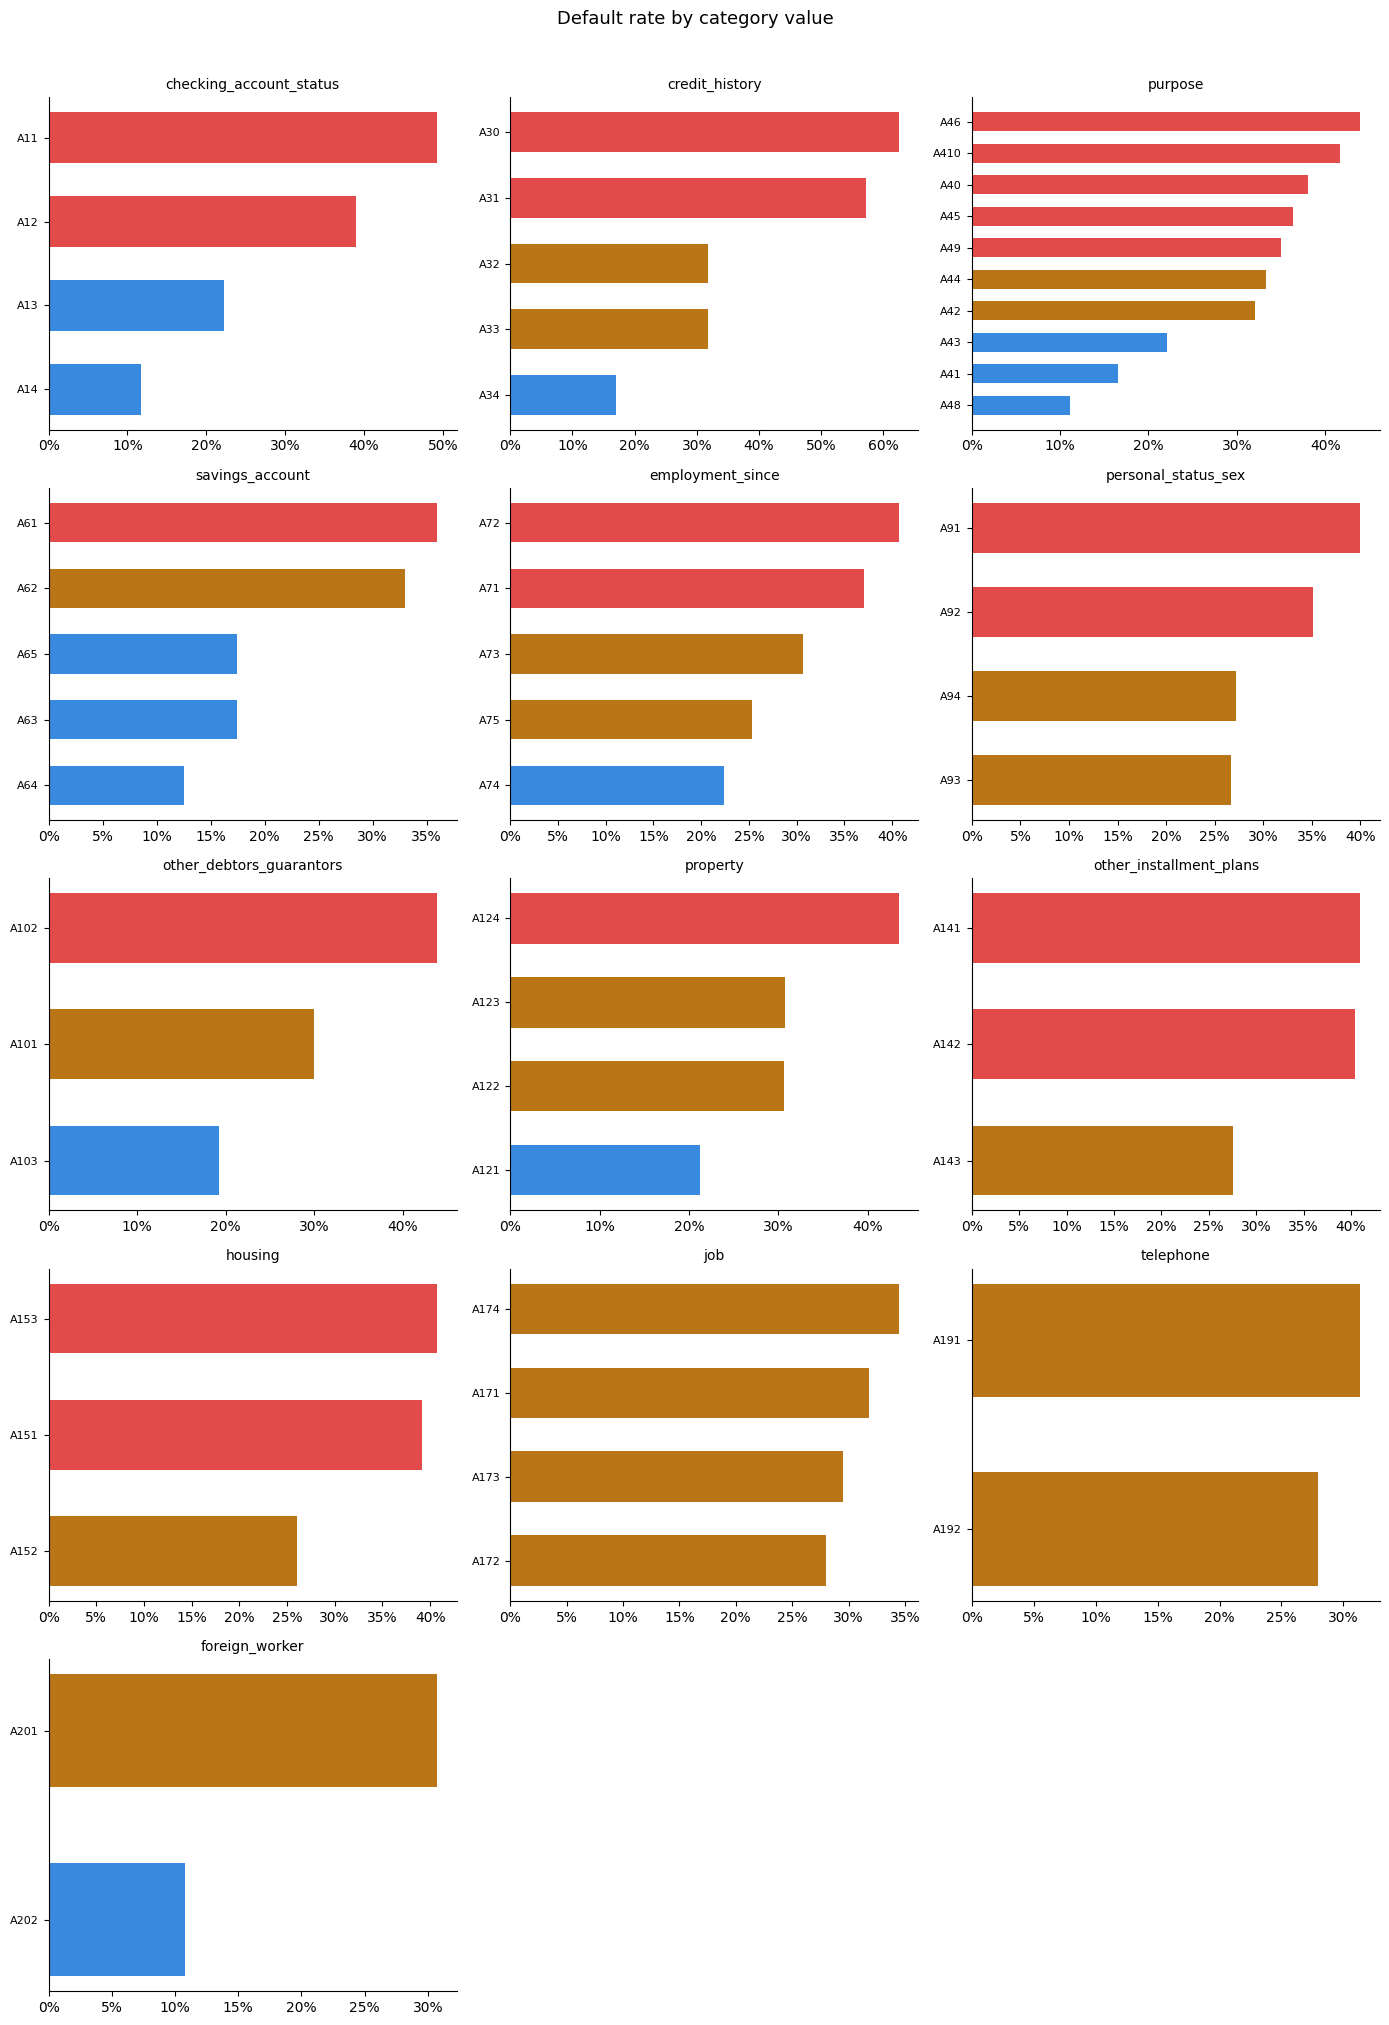

In [184]:
# --- 4b. Default rate per category (the most useful plot) ---
df = X.copy()
df['target'] = binary_target  # 1 = bad credit, 0 = good

n = len(cat_col)
# i want 3 plots per row, then computed number of rows i needed
ncols = 3
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows*4))
axes = axes.flatten()

for i, col in enumerate(cat_col):
    ax = axes[i]
    rate = (df.groupby(col)['target']
              .mean()
              .sort_values(ascending=True))
    colors = ['#E24B4A' if v > 0.35 else
              '#BA7517' if v > 0.25 else
              '#378ADD' for v in rate.values]
    ax.barh(range(len(rate)), rate.values,
            color=colors, edgecolor='none', height=0.6)
    ax.set_yticks(range(len(rate)))
    ax.set_yticklabels(rate.index, fontsize=8)
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.set_title(col, fontsize=10)
    ax.spines[['top','right']].set_visible(False)

for j in range(len(cat_col), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Default rate by category value', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()